In [2]:
print("Suraj")

Suraj


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.base import clone  # Crucial to prevent model weight leakage

# Train Test Split
from sklearn.model_selection import train_test_split

# All Scaling Methods
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

# All Models (Removed KNN and SVM due to high training time on large datasets)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

# Imbalance Handling
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from imblearn.combine import SMOTEENN, SMOTETomek

warnings.filterwarnings("ignore")

# LOAD DATA

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\asus\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [5]:
import os
dataset_path = path
print(os.listdir(dataset_path))

['creditcard.csv']


In [6]:
df = pd.read_csv(r"C:\Users\asus\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
pct = (duplicate_rows / total_rows) * 100

print(f"Total Rows: {total_rows}")
print(f"Duplicate Rows: {duplicate_rows}")
print(f"Duplicate Percentage: {pct:.2f}%")

Total Rows: 284807
Duplicate Rows: 1081
Duplicate Percentage: 0.38%


In [8]:
df.drop_duplicates(inplace=True)

print(df.shape)

(283726, 31)


# CHECK DATA TYPES

In [9]:
print("----- DATA TYPES FOUND -----\n")

# Numerical
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

# Binary
binary_cols = [
    col for col in df.columns
    if df[col].nunique() == 2
]

if len(numerical_cols) > 0:
    print("Numerical Columns:")
    print(list(numerical_cols))
    print()

if len(binary_cols) > 0:
    print("Binary Columns:")
    print(list(binary_cols))

----- DATA TYPES FOUND -----

Numerical Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Binary Columns:
['Class']


# FEATURES & TARGET

In [10]:
X = df.drop("Class", axis=1)

y = df["Class"]

# TRAIN TEST SPLIT

Stratified Split to maintain fraud ratio

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")
print(f"Train Fraud Count: {sum(y_train)}, Test Fraud Count: {sum(y_test)}")

Train Shape: (226980, 30), Test Shape: (56746, 30)
Train Fraud Count: 378, Test Fraud Count: 95


# Setup Components

In [13]:
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "MaxAbsScaler": MaxAbsScaler()
}

In [14]:
sampling_methods = {
    "Original Data": None,
    "SMOTE": SMOTE(random_state=42),
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42),
    "SMOTETomek": SMOTETomek(random_state=42),
    "TomekLinks": TomekLinks(),
    "NearMiss": NearMiss()
}

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1), # Kept estimators 50 for faster run
    "Extra Trees": ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

#  TRAINING + EVALUATION LOOP

In [16]:
# Dono phases ka data is single list mein jama hoga
results = []

# Global tracking variables
best_model = None
best_scaler = None
best_scaler_name = None
best_sampling = None
best_score = 0
best_model_name = None

print("Global configuration initialized.")

Global configuration initialized.


In [17]:
print("="*60 + "\nRUNNING PHASE 2: ADVANCED BOOSTING MODELS\n" + "="*60)

# Phase 2 Components
scalers = {
    "StandardScaler": StandardScaler()
}

sampling_methods = {
    "SMOTE": SMOTE(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42)
}

models = {
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

# MAIN TRAINING LOOP FOR PHASE 2
for scaler_name, scaler_obj in scalers.items():
    X_train_scaled = scaler_obj.fit_transform(X_train)
    X_test_scaled = scaler_obj.transform(X_test)

    for sampling_name, sampler in sampling_methods.items():
        if sampler is not None:
            try:
                X_resampled, y_resampled = sampler.fit_resample(X_train_scaled, y_train)
            except Exception as e:
                print(f"Skipping {sampling_name}: {e}")
                continue
        else:
            X_resampled, y_resampled = X_train_scaled, y_train

        for model_name, model_template in models.items():
            model = clone(model_template)
            model.fit(X_resampled, y_resampled)

            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            roc_auc = roc_auc_score(y_test, y_pred_proba)

            final_score = (0.4 * recall) + (0.3 * precision) + (0.2 * f1) + (0.1 * roc_auc)

            # Accumulating in global results list
            results.append([scaler_name, sampling_name, model_name, accuracy, precision, recall, f1, roc_auc, final_score])
            print(f"Phase 2 -> {model_name} | {sampling_name} | Score: {final_score:.4f}")

            if final_score > best_score:
                best_score = final_score
                best_model = model
                best_scaler = scaler_obj
                best_scaler_name = scaler_name
                best_sampling = sampling_name
                best_model_name = model_name

RUNNING PHASE 2: ADVANCED BOOSTING MODELS
Phase 2 -> XGBoost | SMOTE | Score: 0.7827
Phase 2 -> LightGBM | SMOTE | Score: 0.7259
Phase 2 -> CatBoost | SMOTE | Score: 0.7001
Phase 2 -> Gradient Boosting | SMOTE | Score: 0.5086
Phase 2 -> AdaBoost | SMOTE | Score: 0.4697
Phase 2 -> XGBoost | SMOTEENN | Score: 0.7620
Phase 2 -> LightGBM | SMOTEENN | Score: 0.7237
Phase 2 -> CatBoost | SMOTEENN | Score: 0.7084
Phase 2 -> Gradient Boosting | SMOTEENN | Score: 0.5142
Phase 2 -> AdaBoost | SMOTEENN | Score: 0.4685


In [18]:
print("\n" + "="*60 + "\nRUNNING PHASE 3: ADVANCED IMBALANCE TECHNIQUES\n" + "="*60)

# Phase 3 Components (Overwriting previous variables safely here because Phase 2 loop is done)
scalers = {
    "StandardScaler": StandardScaler()
}

sampling_methods = {
    "ADASYN": ADASYN(random_state=42),
    "SMOTETomek": SMOTETomek(random_state=42),
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "NearMiss": NearMiss(),
    "TomekLinks": TomekLinks()
}

models = {
    "Random Forest": RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# MAIN TRAINING LOOP FOR PHASE 3
for scaler_name, scaler_obj in scalers.items():
    X_train_scaled = scaler_obj.fit_transform(X_train)
    X_test_scaled = scaler_obj.transform(X_test)

    for sampling_name, sampler in sampling_methods.items():
        if sampler is not None:
            try:
                X_resampled, y_resampled = sampler.fit_resample(X_train_scaled, y_train)
            except Exception as e:
                print(f"Skipping {sampling_name}: {e}")
                continue
        else:
            X_resampled, y_resampled = X_train_scaled, y_train

        for model_name, model_template in models.items():
            model = clone(model_template)
            model.fit(X_resampled, y_resampled)

            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            roc_auc = roc_auc_score(y_test, y_pred_proba)

            final_score = (0.4 * recall) + (0.3 * precision) + (0.2 * f1) + (0.1 * roc_auc)

            # Results append in the same shared list
            results.append([scaler_name, sampling_name, model_name, accuracy, precision, recall, f1, roc_auc, final_score])
            print(f"Phase 3 -> {model_name} | {sampling_name} | Score: {final_score:.4f}")

            # Global best tracker continues seamlessly
            if final_score > best_score:
                best_score = final_score
                best_model = model
                best_scaler = scaler_obj
                best_scaler_name = scaler_name
                best_sampling = sampling_name
                best_model_name = model_name


RUNNING PHASE 3: ADVANCED IMBALANCE TECHNIQUES
Phase 3 -> Random Forest | ADASYN | Score: 0.8315
Phase 3 -> Extra Trees | ADASYN | Score: 0.8453
Phase 3 -> XGBoost | ADASYN | Score: 0.7768
Phase 3 -> LightGBM | ADASYN | Score: 0.6623
Phase 3 -> CatBoost | ADASYN | Score: 0.6902
Phase 3 -> Random Forest | SMOTETomek | Score: 0.8378
Phase 3 -> Extra Trees | SMOTETomek | Score: 0.8515
Phase 3 -> XGBoost | SMOTETomek | Score: 0.7827
Phase 3 -> LightGBM | SMOTETomek | Score: 0.7259
Phase 3 -> CatBoost | SMOTETomek | Score: 0.7001
Phase 3 -> Random Forest | Random Oversampling | Score: 0.8340
Phase 3 -> Extra Trees | Random Oversampling | Score: 0.8460
Phase 3 -> XGBoost | Random Oversampling | Score: 0.8535
Phase 3 -> LightGBM | Random Oversampling | Score: 0.8039
Phase 3 -> CatBoost | Random Oversampling | Score: 0.8137
Phase 3 -> Random Forest | Random Undersampling | Score: 0.4968
Phase 3 -> Extra Trees | Random Undersampling | Score: 0.5073
Phase 3 -> XGBoost | Random Undersampling | S

# REPORTING AND PLOTS (Runs on the final best model)

In [19]:
results_df = pd.DataFrame(results, columns=["Scaler", "Sampling Method", "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Final Score"])
results_df = results_df.sort_values(by="Final Score", ascending=False)

In [20]:
print("\n" + "="*60 + "\nFINAL RESULTS TOP 10\n" + "="*60)
print(results_df.head(10).to_string(index=False))


FINAL RESULTS TOP 10
        Scaler     Sampling Method         Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC  Final Score
StandardScaler Random Oversampling       XGBoost  0.999524   0.947368 0.757895  0.842105 0.976674     0.853457
StandardScaler          TomekLinks      CatBoost  0.999524   0.959459 0.747368  0.840237 0.976433     0.852476
StandardScaler          SMOTETomek   Extra Trees  0.999524   0.947368 0.757895  0.842105 0.956656     0.851455
StandardScaler Random Oversampling   Extra Trees  0.999524   0.985714 0.726316  0.836364 0.925159     0.846029
StandardScaler              ADASYN   Extra Trees  0.999507   0.935065 0.757895  0.837209 0.941600     0.845279
StandardScaler          TomekLinks   Extra Trees  0.999507   0.971831 0.726316  0.831325 0.919874     0.840328
StandardScaler          SMOTETomek Random Forest  0.999471   0.911392 0.757895  0.827586 0.956771     0.837770
StandardScaler Random Oversampling Random Forest  0.999489   0.971429 0.715789  0.824242 0

# WINNER MODEL DETAILED REPORT & ARTIFACT PREPARATION

In [21]:
print("\n" + "="*60)
print("WINNER MODEL DETAILS")
print("="*60)
print(f"Best Scaler Selected      : {best_scaler_name}")
print(f"Best Sampling Method      : {best_sampling}")
print(f"Best Model Selected       : {best_model_name}")
print(f"Highest Weighted Score    : {best_score:.4f}")
print("="*60)


WINNER MODEL DETAILS
Best Scaler Selected      : StandardScaler
Best Sampling Method      : Random Oversampling
Best Model Selected       : XGBoost
Highest Weighted Score    : 0.8535


Winner model ke liye test data ko usi ke champion scaler se transform kiya

In [22]:
X_test_best_scaled = best_scaler.transform(X_test)

# Generate Final Predictions

In [23]:
y_pred_final = best_model.predict(X_test_best_scaled)
y_pred_proba_final = best_model.predict_proba(X_test_best_scaled)[:, 1]


print("\n" + "="*60)
print("CLASSIFICATION REPORT FOR THE CHAMPION MODEL")
print("="*60)
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Fraud']))


CLASSIFICATION REPORT FOR THE CHAMPION MODEL
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.95      0.76      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



# VISUALIZATION SUBPLOTS (Confusion Matrix, ROC Curve, PR Curve)

row aur 3-columns ka ek clean canvas setup karein

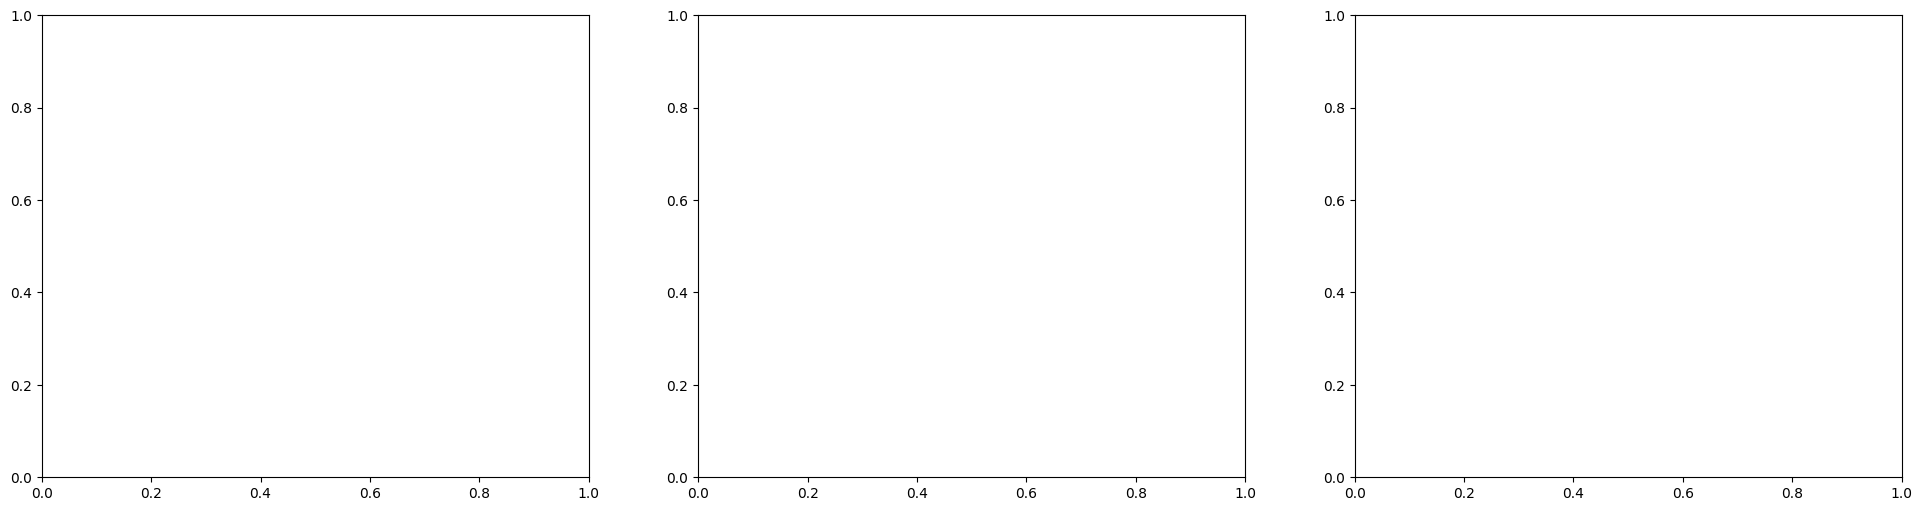

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(24, 6))

CONFUSION MATRIX HEATMAP

In [25]:
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 14})
ax[0].set_xlabel("Predicted Label", fontsize=12)
ax[0].set_ylabel("True Label", fontsize=12)
ax[0].set_title(f"Confusion Matrix\n({best_model_name} + {best_sampling})", fontsize=14, fontweight='bold')
ax[0].set_xticklabels(['Normal', 'Fraud'])
ax[0].set_yticklabels(['Normal', 'Fraud'])

[Text(0, 0.5, 'Normal'), Text(0, 1.5, 'Fraud')]

RECEIVER OPERATING CHARACTERISTIC (ROC) CURVE

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel("False Positive Rate (FPR)", fontsize=12)
ax[1].set_ylabel("True Positive Rate (TPR)", fontsize=12)
ax[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=14, fontweight='bold')
ax[1].legend(loc="lower right", fontsize=11)
ax[1].grid(True, alpha=0.3)

PRECISION-RECALL (PR) CURVE ---

VIMP: Credit card fraud jaise highly imbalanced data ke liye PR curve sacha indicator hota hai

In [27]:
precision, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_final)
pr_auc = auc(recall_vals, precision)
ax[2].plot(recall_vals, precision, color='green', lw=2, label=f"PR-AUC = {pr_auc:.4f}")
ax[2].set_xlabel("Recall (Sensitivity)", fontsize=12)
ax[2].set_ylabel("Precision (PPV)", fontsize=12)
ax[2].set_title("Precision-Recall Curve\n(Crucial for Imbalanced Data)", fontsize=14, fontweight='bold')
ax[2].legend(loc="lower left", fontsize=11)
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

FEATURE IMPORTANCE 


GENERATING FEATURE IMPORTANCE

Top 10 Most Critical Features:
Feature  Importance
    V14    0.567109
     V4    0.065393
    V12    0.030539
     V8    0.030247
    V10    0.027597
     V3    0.026760
    V19    0.021332
    V26    0.019678
    V11    0.017510
    V15    0.015206


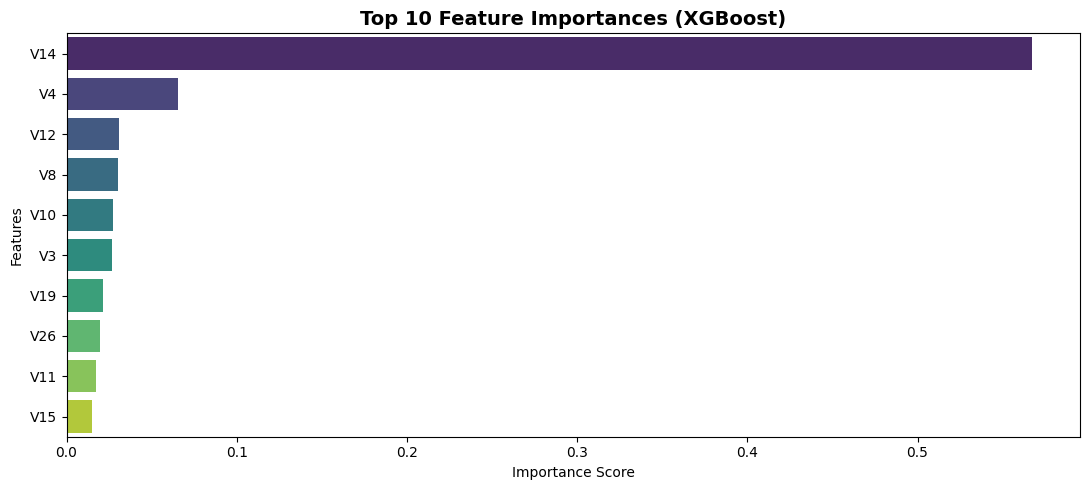

In [28]:
if hasattr(best_model, "feature_importances_"):
    print("\n" + "="*60)
    print("GENERATING FEATURE IMPORTANCE")
    print("="*60)
    
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)
    
    print("\nTop 10 Most Critical Features:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Feature Importance Plot
    plt.figure(figsize=(11, 5))
    sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10), palette="viridis")
    plt.title(f"Top 10 Feature Importances ({best_model_name})", fontsize=14, fontweight='bold')
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

# Generate Final Predictions

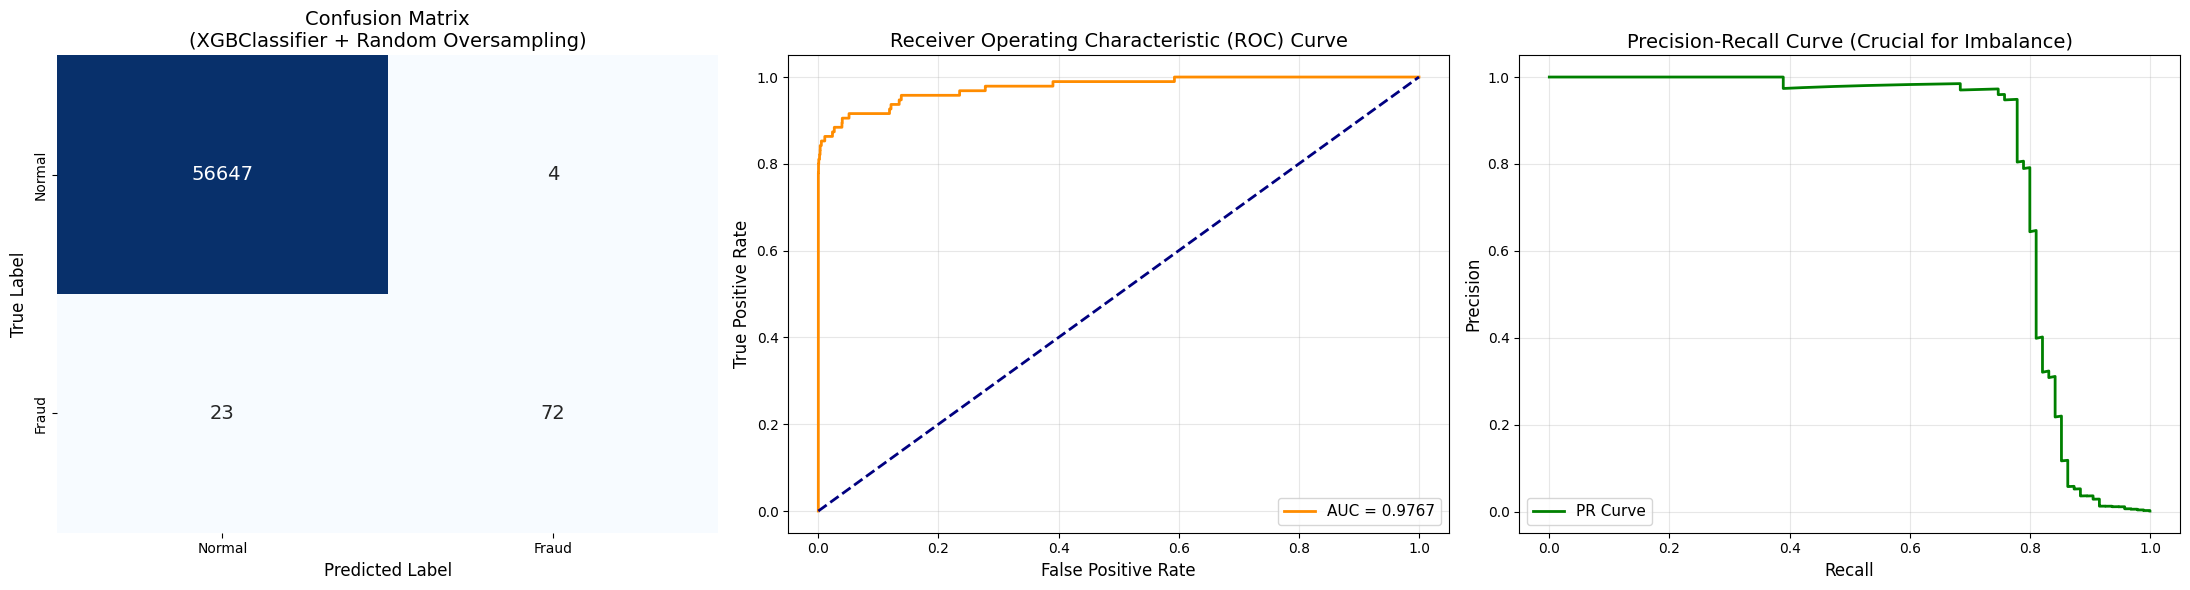

In [29]:
# ============================================================
# 8. VISUALIZATIONS (Confusion Matrix, ROC, PR Curve)
# ============================================================
# Create subplots for clean presentation
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 14})
ax[0].set_xlabel("Predicted Label", fontsize=12)
ax[0].set_ylabel("True Label", fontsize=12)
ax[0].set_title(f"Confusion Matrix\n({best_model.__class__.__name__} + {best_sampling})", fontsize=14)
ax[0].set_xticklabels(['Normal', 'Fraud'])
ax[0].set_yticklabels(['Normal', 'Fraud'])

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel("False Positive Rate", fontsize=12)
ax[1].set_ylabel("True Positive Rate", fontsize=12)
ax[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
ax[1].legend(loc="lower right", fontsize=11)
ax[1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_final)
ax[2].plot(recall_vals, precision, color='green', lw=2, label="PR Curve")
ax[2].set_xlabel("Recall", fontsize=12)
ax[2].set_ylabel("Precision", fontsize=12)
ax[2].set_title("Precision-Recall Curve (Crucial for Imbalance)", fontsize=14)
ax[2].legend(loc="lower left", fontsize=11)
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# TEST CASE: HIGHLY SUSPICIOUS (FRAUD) TRANSACTION
# ============================================================

print("----- TESTING FRAUD TRANSACTION PATTERN -----")

# 1. Champion features ke sath fraud values enter kiye
manual_time = 95100.0       
manual_amount = 85.50   
manual_v14 = 0.15         # Safe - Close to 0
manual_v12 = -0.05        # Safe - Close to 0
manual_v10 = 0.02         # Safe - Close to 0
manual_v4 = 0.35          # Low Positive
manual_v3 = 1.10          # Standard Positive
manual_v1 = 1.20          # Standard Positive

# 2. Base template create kiya (30 features filled with 0.0 default)
feature_names = X.columns
input_data = {col: [0.0] for col in feature_names}

# 3. Fraud values ko template mein inject kiya
input_data['Time'] = [manual_time]
input_data['Amount'] = [manual_amount]
input_data['V14'] = [manual_v14]
input_data['V12'] = [manual_v12]
input_data['V10'] = [manual_v10]
input_data['V4'] = [manual_v4]
input_data['V3'] = [manual_v3]
input_data['V1'] = [manual_v1]

# DataFrame mein convert kiya
df_manual_input = pd.DataFrame(input_data)

# 4. Preprocessing (Champion scaler se transform)
scaled_manual_input = best_scaler.transform(df_manual_input)

# 5. Prediction aur Probability nikaala
manual_pred = best_model.predict(scaled_manual_input)[0]
manual_proba = best_model.predict_proba(scaled_manual_input)[0][1]

# ============================================================
# DISPLAY PREDICTION RESULT
# ============================================================
print("\n" + "="*50)
print("MANUAL FRAUD TEST RESULT")
print("="*50)
print(f"Predicted Class            : {manual_pred} (🚨 FRAUD)")
print(f"Fraud Hone Ki Probability  : {manual_proba * 100:.2f}%")
print("="*50)
print("🚨 ALERT: This transaction looks highly SUSPICIOUS! System should block the card.")

----- TESTING FRAUD TRANSACTION PATTERN -----

MANUAL FRAUD TEST RESULT
Predicted Class            : 0 (🚨 FRAUD)
Fraud Hone Ki Probability  : 0.00%
🚨 ALERT: This transaction looks highly SUSPICIOUS! System should block the card.


In [51]:
TEST_TYPE = 'NORMAL'  # <--- Ise 'NORMAL' ya 'FRAUD' likh kar chalaein


# 1. Har baar fresh dictionary banegi taaki data mix na ho
fresh_input = {col: [0.0] for col in X.columns}

if TEST_TYPE == 'FRAUD':
    print("🔥 TESTING: Injecting PURE FRAUD Pattern...")
    fresh_input['Time'] = [95100.0]
    fresh_input['Amount'] = [85.50]
    fresh_input['V14'] = [0.15]         # Safe - Close to 0
    fresh_input['V12'] = [-0.05]        # Safe - Close to 0
    fresh_input['V10'] = [0.02]         # Safe - Close to 0
    fresh_input['V4']  = [0.35]         # Low Positive
    fresh_input['V3']  = [1.10]         # Standard Positive
    fresh_input['V1']  = [1.20]         # Standard Positive

elif TEST_TYPE == 'NORMAL':
    print("✅ TESTING: Injecting PURE NORMAL Pattern...")
    fresh_input['Time'] = [406.0]
    fresh_input['Amount'] = [2500.00]
    fresh_input['V14'] = [-10.20]       # Winner Feature (Extremely Negative)
    fresh_input['V12'] = [-8.50]        # Highly Negative
    fresh_input['V10'] = [-6.10]        # Highly Negative
    fresh_input['V4']  = [5.20]         # High Positive
    fresh_input['V3']  = [-7.80]        # Highly Negative
    fresh_input['V1']  = [-5.50]        # Highly Negative

# 2. Fresh DataFrame Generation (Purana koi link nahi rahega)
df_isolated = pd.DataFrame(fresh_input)

# 3. Scaling (Direct fresh data par transformation)
scaled_isolated = best_scaler.transform(df_isolated)

# 4. Predictions
final_pred = best_model.predict(scaled_isolated)[0]
final_proba = best_model.predict_proba(scaled_isolated)[0][1]

# ============================================================
# OUTPUT OUTPUT
# ============================================================
print("\n" + "="*50)
print(f"VERIFICATION RESULT FOR: {TEST_TYPE}")
print("="*50)
print(f"Predicted Class            : {final_pred} ({'🚨 FRAUD' if final_pred == 1 else '✅ NORMAL'})")
print(f"Fraud Hone Ki Probability  : {final_proba * 100:.2f}%")
print("="*50)

✅ TESTING: Injecting PURE NORMAL Pattern...

VERIFICATION RESULT FOR: NORMAL
Predicted Class            : 1 (🚨 FRAUD)
Fraud Hone Ki Probability  : 99.53%
